In [2]:
import torch 
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim
import time
import matplotlib.pyplot as plt

In [3]:
device = torch.device('mps')
device

device(type='mps')

In [4]:
class CIFAR10:
    def __init__(self):
        # augmentation
        self.transform = transforms.Compose(
            [transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
        )
        self.trainloader = None 
        self.testloader = None
        self.valloader = None
        self.batch_size = 4 # NOTE: each 12500 training batch contains 4 images
        self.classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

    def generate(self):
        # train dataset
        trainset = torchvision.datasets.CIFAR10(root="./data", train=True, 
                                                download=True, transform=self.transform)
        self.trainloader = torch.utils.data.DataLoader(trainset, batch_size=self.batch_size, 
                                                       shuffle=True, num_workers=2)

        # test dataset
        # split testset into test and validation
        testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=self.transform)
        validationset, testset = torch.utils.data.random_split(testset, [0.8, 0.2])
        self.testloader = torch.utils.data.DataLoader(testset, batch_size=self.batch_size,
                                         shuffle=False, num_workers=2)
        self.valloader = torch.utils.data.DataLoader(validationset, batch_size=self.batch_size,
                                                     shuffle=False, num_workers=2)

cifar_data = CIFAR10() 
cifar_data.generate()

Files already downloaded and verified
Files already downloaded and verified


In [5]:
# len(cifar_data.trainloader) # 
# 4 * 12500
len(cifar_data.valloader)

2000

In [6]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(cifar_data.trainloader)
images, labels = next(dataiter)

# imshow(images[0])
print("target", cifar_data.classes[labels[0]])
print(images[0].shape)


target ship
torch.Size([3, 32, 32])


In [7]:
images[0]

tensor([[[ 0.6078,  0.5294,  0.5294,  ...,  0.5373,  0.5294,  0.5843],
         [ 0.6235,  0.5529,  0.5608,  ...,  0.5765,  0.5608,  0.6078],
         [ 0.6078,  0.5294,  0.5294,  ...,  0.5529,  0.5451,  0.5922],
         ...,
         [-0.0431, -0.0196,  0.0275,  ..., -0.4510, -0.5373, -0.5608],
         [-0.1216, -0.0667, -0.0353,  ..., -0.4431, -0.5608, -0.6235],
         [-0.1843, -0.1451, -0.1137,  ..., -0.4588, -0.5608, -0.6235]],

        [[ 0.7255,  0.6941,  0.6941,  ...,  0.7020,  0.7020,  0.7333],
         [ 0.7569,  0.7333,  0.7333,  ...,  0.7412,  0.7412,  0.7647],
         [ 0.7569,  0.7255,  0.7255,  ...,  0.7255,  0.7176,  0.7490],
         ...,
         [-0.0118,  0.0118,  0.0667,  ..., -0.4039, -0.4980, -0.5216],
         [-0.1059, -0.0510, -0.0118,  ..., -0.3961, -0.5137, -0.5843],
         [-0.1765, -0.1451, -0.1059,  ..., -0.4118, -0.5216, -0.5843]],

        [[ 0.7882,  0.7647,  0.7804,  ...,  0.7882,  0.8118,  0.8431],
         [ 0.8196,  0.8039,  0.8196,  ...,  0

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 32, 5)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(32, 64, 5)
        self.conv4 = nn.Conv2d(64, 128, 5)
        self.bn3 = nn.BatchNorm2d(128)
        self.fc1 = nn.Linear(128 * 2 * 2, 120)
        self.fc2 = nn.Linear(120, 10)
        # self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        # x = self.bn1(x)
        x = self.conv2(x)
        # x = self.bn1(x)
        x = F.relu(x)
        x =  self.pool(x)

        x = self.conv3(x)
        x = F.relu(x)
        # x = self.bn2(x)
        x = self.conv4(x)
        # x = self.bn3(x)
        x = F.relu(x)
        x =  self.pool(x)

        self.features = x # save features for xgboost
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [84]:
class ProgressNet:
    def __init__(self, epoch_iteration):
        self.epoch_iteration = epoch_iteration
        self.trainloss = []
        self.valloss = []
        self.net = Net()
        # enable MAC GPU
        self.net.to(device)
        
    def _net_nograd(self):
        val_loss = 0
        with torch.no_grad():
            for i, data in enumerate(cifar_data.valloader):
                images, targets = data
                images, targets = images.to(device), targets.to(device)
                out = self.net(images)
                loss = self.criterion(out, targets)
                val_loss += loss.item()
            return val_loss
        
    def _iterate_model(self):
        train_loss = 0
        runningloss = 0
        for i, data in enumerate(cifar_data.trainloader):
            images, targets = data
            images, targets = images.to(device), targets.to(device)
            # zero out gradients
            self.optimizer.zero_grad()
            # forward pass
            out = self.net(images)
            loss = self.criterion(out, targets)
            # backward pass
            loss.backward()
            self.optimizer.step()
            runningloss += loss.item()
            if (i+1) % 200 == 0:
                print(f"running loss: {runningloss / 200}") 
                runningloss= 0
            train_loss += loss.item()
        
        train_loss /= len(cifar_data.trainloader)
        self.net.eval()
        # check on validation set 
        valloss = self._net_nograd()
        valloss /= len(cifar_data.valloader)
        print(f"train_loss: {train_loss}")
        print(f"val_loss: {valloss}")
        self.valloss.append(valloss)
        self.trainloss.append(train_loss)

    def run(self):
        start_time = time.time()
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.SGD(self.net.parameters(), lr=0.001, momentum=0.9)
        log_loss = []
        for epoch in range(self.epoch_iteration):
            print(f"epoch #{epoch} progressing")
            self._iterate_model()
            print(f"epoch #{epoch} finished")
            # log_loss.append(total_loss)
        self._save_net()
        print(f"time took: {time.time() - start_time}sec")
        
    def _save_net(self):
        # save model weights
        path_save_model = f"cifar_net_train.pth"
        print(f"finished training & saving model at :{path_save_model}")
        torch.save(self.net.state_dict(), path_save_model)


In [85]:
progress = ProgressNet(epoch_iteration=3)
if not os.path.exists(f"cifar_net_train.pth"):
    progress.run()

epoch #0 progressing
running loss: 2.3042845976352693
running loss: 2.303435287475586
running loss: 2.2951110112667084
running loss: 2.2664101058244706
running loss: 2.205067155957222
running loss: 2.1427418571710586
running loss: 2.1367743569612503
running loss: 2.0446215814352033
running loss: 2.0459236043691633
running loss: 2.0374065291881562
running loss: 2.019559888243675
running loss: 1.9864735114574432
running loss: 1.9156870603561402
running loss: 1.9446238267421723
running loss: 1.9161096549034118
running loss: 1.8430187213420868
running loss: 1.834985965490341
running loss: 1.838991667330265
running loss: 1.8582430678606032
running loss: 1.808435320854187
running loss: 1.768584778904915
running loss: 1.7255477076768875
running loss: 1.738205888569355
running loss: 1.7785501080751418
running loss: 1.7396212044358252
running loss: 1.7074814945459367
running loss: 1.7035621991753578
running loss: 1.66921124458313
running loss: 1.6332433360815048
running loss: 1.6444981801509857

In [86]:
progress.trainloss

[1.6996085826897622, 1.1977299076637626, 0.9773081553990207]

In [87]:
progress.valloss

[1.3302721458822488, 1.0717269924385473, 1.036750351017341]

In [88]:
def plot_curve():
    fig = plt.figure()
    plt.figure().clear()
    plt.plot(progress.trainloss, label="trainingloss", color="green")
    plt.plot(progress.valloss, label="validationloss", color="blue")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
    plt.close()
# progress.trainloss

<Figure size 640x480 with 0 Axes>

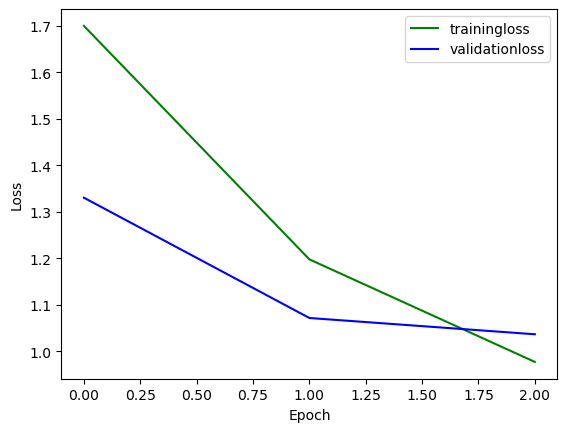

In [89]:
plot_curve()

In [9]:
# load saved model
net = Net()
net.load_state_dict(torch.load(f"cifar_net_train.pth", weights_only=True))

correct = 0
total = 0
with torch.no_grad():
    for data in cifar_data.testloader:
        images, target = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

print(f'Accuracy of the network on the 500*4 test images: {100 * correct // total} %')


Accuracy of the network on the 500*4 test images: 62 %


2000

In [28]:
# list(progress.net.named_parameters())

In [91]:
# progress.net.features

In [77]:
net = Net()
net.load_state_dict(torch.load(f"cifar_net_train.pth", weights_only=True))
xtrain_features, ytrain = [], []
with torch.no_grad():
    for i, data in enumerate(cifar_data.trainloader):
        images, targets = data
        _ = net(images)
        features_layer = net.features
        xtrain_features.append(features_layer)
        ytrain.append(targets)
        # print(features_layer.shape)
        # print(features_layer[0])

In [78]:
xtrain_features[100].shape

torch.Size([4, 128, 2, 2])

In [79]:
x_train_torch = torch.stack(xtrain_features, dim=1)
x_train_torch.shape

torch.Size([4, 12500, 128, 2, 2])

In [82]:
import xgboost as xgb

xtrain_reshaped = x_train_torch.reshape(4 * x_train_torch.shape[1], -1)
xtrainnp = xtrain_reshaped.numpy()
xtrainnp.shape

(50000, 512)

In [83]:
ytrain_torch = torch.stack(ytrain, dim=1)
ytrain_torch = ytrain_torch.reshape(4 * x_train_torch.shape[1])
ytrain_np = ytrain_torch.numpy()
ytrain_np.shape

(50000,)

In [84]:
dtrain = xgb.DMatrix(xtrainnp, label=ytrain_np)

In [85]:
dtrain

In [86]:
xgb_params = {}
xgb_params["objective"] = "multi:softmax"
xgb_params["num_class"] = 10
xgb_params["eval_metric"] = "mlogloss"
xgb_params["max_depth"] = 6

num_round = 400
xgb_model = xgb.train(xgb_params, dtrain, num_round)

In [89]:

xgb_predictions = xgb_model.predict(dtrain)

In [98]:
correct = 0
for target, predicted in zip(ytrain_np, xgb_predictions):
    pass
    #print((target))
    # print(predicted)
    # correct += (target == predicted)
# print(correct)

In [101]:
#testing xgb model

net = Net()
net.load_state_dict(torch.load(f"cifar_net_train.pth", weights_only=True))
xtest_features, ytest = [], []
with torch.no_grad():
    for i, data in enumerate(cifar_data.testloader):
        images, targets = data
        _ = net(images)
        features_layer = net.features
        xtest_features.append(features_layer)
        ytest.append(targets)
        # print(features_layer.shape)
        # print(features_layer[0])

x_test_torch = torch.stack(xtest_features, dim=1)
xtest_reshaped = x_test_torch.reshape(4 * x_test_torch.shape[1], -1)
xtestnp = xtest_reshaped.numpy()

ytest_torch = torch.stack(ytest, dim=1)
ytest_torch = ytest_torch.reshape(4 * x_test_torch.shape[1])
ytest_np = ytest_torch.numpy()

dtest = xgb.DMatrix(xtestnp, label=ytest_np)
xgb_predict = xgb_model.predict(dtest)

In [107]:
correct = 0
for target, predicted in zip(ytest_np, xgb_predict):
    correct += (target == float(predicted))
# print(correct)
# print(total)
total = ytest_np.shape[0]
print( f"{100 * correct // total} % accuracy")

70 % accuracy
